[]
[0.0, 5.303315364902999e-05, 0.00014849474108136613, 0.00024415668681178413, 0.000340023953219705, 0.0004352867780002458, 0.0005321339967123609, 0.000628863404499012, 0.0007253011552946306, 0.0008210824247658456, 0.0009160141155529586, 0.0010100047638763265, 0.0011023876449836186, 0.0011930791088151475, 0.00128128645394161, 0.001366736356623035, 0.0014486457882448107, 0.0015264121444161255, 0.0015991393598810335, 0.001665911710837271, 0.0017258061291380222, 0.0017777291909752526, 0.0018204845412759327, 0.001852794669039393, 0.0018732620688235275, 0.0018803959123118523, 0.0018725767071066388, 0.0018480725868164534, 0.0018050191555241176, 0.0017414674929260331, 0.0016552966480314324, 0.0015453045044142918, 0.0014086751409763385, 0.001256977722667506, 0.001079010669903018, 0.0008664722963764346, 0.0008485152266924584, 0.0008275830532242867, 0.0007875883297586374, 0.0008555276031890619, 0.0009046316883861763, 0.0008931131331488873, 0.0008858934399788854, 0.0008048600929463606, 0.0006501

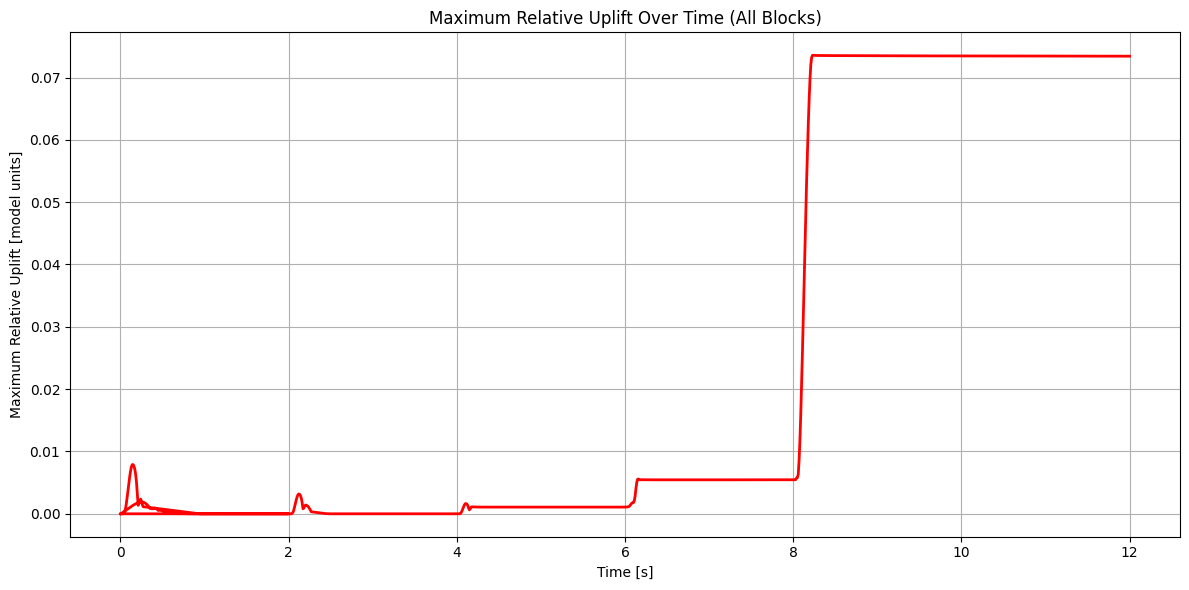

First few times: [0.0, 0.010003347881138325, 0.020013565197587013, 0.03000602498650551, 0.04000945761799812, 0.05000763013958931, 0.060001686215400696, 0.07000037282705307, 0.08001159876585007, 0.09001229703426361]
First few max uplift values: [0.0, 5.303315364902999e-05, 0.00014849474108136613, 0.00024415668681178413, 0.000340023953219705, 0.0004352867780002458, 0.0005321339967123609, 0.000628863404499012, 0.0007253011552946306, 0.0008210824247658456]


In [6]:
import csv
import matplotlib.pyplot as plt

# === CONFIGURATION ===
csv_file = 'relative_uplift_timeseries_06.csv'

# === LOAD DATA ===
times = []
block_names = []
uplift_data = {}

with open(csv_file, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)

    # Header now has: ['Step', 'Time', 'B-1-1', ...]
    block_names = header[2:]   # skip Step and Time columns

    for block in block_names:
        uplift_data[block] = []

    for row in reader:
        time_str = row[1]
        if time_str:
            times.append(float(time_str))
        else:
            times.append(None)

        for i, block in enumerate(block_names):
            val = row[i + 2]
            uplift_data[block].append(float(val) if val else None)

# === COMPUTE MAX UPLIFT AT EACH TIME STEP ===
max_uplift = []
print(max_uplift)

for i in range(len(times)):
    # Gather all uplift values at time index i
    values_at_t = [
        uplift_data[block][i]
        for block in block_names
        if uplift_data[block][i] is not None
    ]

    if values_at_t:
        max_uplift.append(max(values_at_t))
    else:
        max_uplift.append(None)
print(max_uplift)
# === PLOT MAX UPLIFT ===
plt.figure(figsize=(12, 6))
plt.plot(times, max_uplift, color='red', linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Maximum Relative Uplift [model units]')
plt.title('Maximum Relative Uplift Over Time (All Blocks)')
plt.grid(True)
plt.tight_layout()
plt.show()

print("First few times:", times[:10])
print("First few max uplift values:", max_uplift[:10])

